In [1]:
# Behzad Ghabaei
# CS 82A - Data Science
# module 6_lab.ipynb
# Query Like an Analyst
# store_orders.csv
# store_customers.csv
# Instructor Seno
# 10/6/2026

## Step 1: Load the CSVs and build the database
#### Load both CSVs with pandas, connect to a new store.db, and pour each DataFrame in as tables named orders and customers (Tutorial 1 pattern).
#### You should see: running pd.read_sql("SELECT name FROM sqlite_master", con) lists both tables.

In [2]:
# 1. Connect to (or create) the database file
# 2. Load the CSV files into pandas DataFrames
# 3. Pour the DataFrames into the SQLite database as tables
#  lists both tables.

In [3]:
import sqlite3
import pandas as pd

con = sqlite3.connect("store.db")

df_customers = pd.read_csv("store_customers.csv")
df_orders = pd.read_csv("store_orders.csv")

df_customers.to_sql("customers", con, index=False, if_exists="replace")
df_orders.to_sql("orders", con, index=False, if_exists="replace")

pd.read_sql("SELECT name FROM sqlite_master", con)

,name
0,customers
1,orders


## Step 2: First look
#### Query the first 5 rows of orders (Tutorial 2 pattern).
#### You should see: 5 rows with order_id, customer_id, product, category, amount, order_date.
```
pd.read_sql("SELECT * FROM employees LIMIT 5", con)
```

In [4]:
# pd.read_sql("SELECT * FROM customers LIMIT 5", con)
pd.read_sql("SELECT * FROM orders LIMIT 5", con)

,order_id,customer_id,product,category,amount,order_date
0,5000,4,paper,office,14.09,2026-05-25
1,5001,15,planner,office,51.86,2026-05-08
2,5002,34,shelf,furniture,116.25,2026-06-03
3,5003,2,granola,snacks,19.72,2026-05-19
4,5004,17,monitor,electronics,284.80,2026-05-10


## Step 3: Filter and sort
#### Write one query returning all orders over 100 dollars, sorted by amount from highest to lowest (Tutorial 3 skeleton).
#### You should see: the top row is the seeded 499 dollar order.

In [5]:
filter_and_sort = """
SELECT order_id, customer_id, product, category, amount, order_date
FROM orders
WHERE amount > 100
ORDER BY amount DESC
LIMIT 10
"""
pd.read_sql(filter_and_sort, con)

,order_id,customer_id,product,category,amount,order_date
0,5153,20,dock,electronics,499.00,2026-05-25
1,5140,30,headset,electronics,295.36,2026-05-26
2,5047,901,headset,electronics,293.79,2026-05-15
3,5150,903,monitor,electronics,293.35,2026-06-06
4,5014,6,monitor,electronics,287.83,2026-05-22
5,5113,4,headset,electronics,286.65,2026-05-15
6,5034,29,headset,electronics,286.36,2026-05-14
7,5149,8,headset,electronics,286.30,2026-05-05
8,5004,17,monitor,electronics,284.80,2026-05-10
9,5174,11,headset,electronics,277.24,2026-05-26


## Step 4: Aggregate by category
#### One query: for each product category, the number of orders and the average amount, named with AS, sorted by average amount descending (Tutorial 4 pattern). In markdown, one sentence: which category earns the most per order?
#### You should see: one row per category with n and avg_amount columns.

In [6]:
aggregate_by_category = """
SELECT category, COUNT(*) AS n, AVG(amount) AS avg_amount
FROM orders
GROUP BY category
ORDER BY avg_amount DESC;
"""
pd.read_sql(aggregate_by_category, con)


,category,n,avg_amount
0,electronics,60,190.569500
1,furniture,46,146.251522
2,office,51,30.132549
3,snacks,43,14.619767


#### The electronics category earns the most per order, bringing in an average of approximately $190.57 per transaction.

## Step 5: Join for spend by city
#### Write the JOIN (Tutorial 5 pattern): total spend per customer city, using the key the data dictionary gives you, sorted by total descending.
#### Hint: SUM of the order amount, grouped by the customers table’s city column.
#### You should see: a short table of cities with totals.

In [7]:
join_for_spend_by_city = """
SELECT c.city, SUM(o.amount) AS total_spend
FROM orders o
JOIN customers c ON o.customer_id = c.customer_id
GROUP BY c.city
ORDER BY total_spend DESC;
"""
df_city_spend = pd.read_sql(join_for_spend_by_city, con)


## Step 6: The row-count audit (markdown cell)
#### Count the rows of orders and the rows your join produced (before grouping, or by summing order counts per city). They differ. Explain why in 2–3 sentences: the data contains 5 orders whose customer_id matches no customer.

In [8]:
# Check total transaction row count vs merged row count
total_orders = pd.read_sql("SELECT COUNT(*) AS total FROM orders", con)
merged_orders = pd.read_sql("SELECT COUNT(*) AS total FROM orders o JOIN customers c ON o.customer_id = c.customer_id", con)

print("total orders: ",total_orders)
print("merged orders: ",merged_orders)


total orders:     total
0    200
merged orders:     total
0    195


#### The original orders table contains 200 rows, but the inner join produces only 195 rows. This discrepancy occurs because the data includes 5 orders with placeholder customer IDs (900, 901, 902, 903, and 904) that do not exist in the customers database. Because an inner join requires a matching key in both tables, these 5 orphaned records are omitted from the output.

## Step 7: Chart a query result
#### Take your Step 5 result (already a DataFrame thanks to read_sql) and bar-chart total spend by city, fully labeled with title and units.
#### You should see: a labeled bar chart born from SQL.

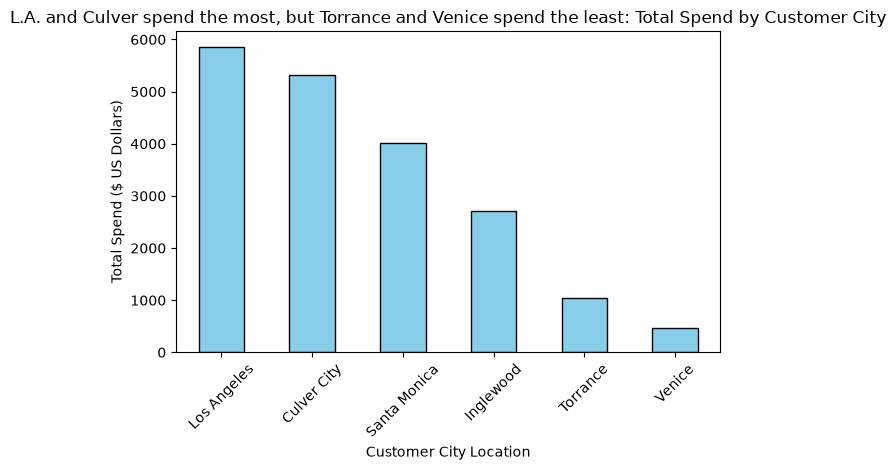

In [9]:
import matplotlib.pyplot as plt

df_city_spend.plot(x="city", y="total_spend", kind="bar", legend=False, color="skyblue", edgecolor="black")

plt.title("L.A. and Culver spend the most, but Torrance and Venice spend the least: Total Spend by Customer City")
plt.xlabel("Customer City Location")
plt.ylabel("Total Spend ($ US Dollars)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## Step 8: Your own question
#### Write one NEW business question about this data in plain English, then answer it with your own SQL query and state the answer in markdown.

#### Business Question: Which 3 unique items have the highest amount among the entire inventory?

In [10]:
your_own_question = """
SELECT product, category, amount AS single_sale_max
FROM orders
ORDER BY amount DESC
LIMIT 3;
"""
pd.read_sql(your_own_question, con)


,product,category,single_sale_max
0,dock,electronics,499.00
1,headset,electronics,295.36
2,headset,electronics,293.79


#### For the highest amount, we will call it "the highest transaction sales volumes" coming from the electronics category valued at \\$499.00, followed closely by a headset (\\$295.36) and another headset (\\$293.79).

## Step 9: Ethics note and safe push (markdown cell)
#### This database holds names and cities. In 2–3 sentences: what would you strip or aggregate before sharing results publicly, and why? Then make sure your notebook does NOT display a full dump of the customers table, and push only the notebook (never store.db or the customer CSV).

#### Before sharing database information and data publicly, I would entirely drop customer names and place the city variables in geographical regions or zip codes to protect Personal Identifiable Information (PII). Concealing or removing these personal individual identifiers prevents being at fault for privacy risks, in order to prevent information misuse or malicious actors from matching any identities that is not their own. To maintain a secure notebook output that can be shared and reused, your file must be saved from public exposure (version control automatically done on github often) in the store.db and any raw input customer information showing in CSV sheets.

## Behzad Ghabaei - End Of Lab